#### Summary:
In this notebook we read in the ChromVAR results and then perform linear mixed effects to find associations across datasets between motif accessibility and donor phenotypes.

In [1]:
library(Signac)
library(Seurat)
library(JASPAR2020)
library(TFBSTools)
library(BSgenome.Hsapiens.UCSC.hg38)
library(patchwork)
library(readr)
library(stringr)
library(dplyr)
set.seed(1234)

#### Send to channel code
library(parallel)
library(plyr)
library(ggpubr)
library(car)
library(qvalue)

library(pheatmap)
library(RColorBrewer)
library(beeswarm)

library(lmerTest)
library(tictoc)
library(data.table)
library(meta)

Attaching SeuratObject

Attaching sp



Loading required package: BSgenome

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, append, as.data.frame, basename, cbind, colnames,
    dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep,
    grepl, intersect, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, setdiff, sort, table, tapply,
    union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges


Attaching package: ‘IRanges’


The following object is masked from ‘package:sp’:

    

In [2]:
cell_types <- c('beta','alpha','delta','gamma','acinar','ductal',
               'stellate','endothelial','immune')

In [3]:
we_outdir <- '/path/to/outdir/for/Alberta/chromVAR'
gh_ref_dir <- 'non-diabetic-islet-multiomics/references'

In [4]:
chromvar_dir <- '/path/to/additional/inputs/ATAC/ChromVAR'

# 1. Read in ChromVAR outputs

## First read in a few basic refs

In [5]:
TFClass_Lookup <- read_csv(file.path(gh_ref_dir,"220907_WE_Motif_to_Gene_By_Subfam_Complete.JASPAR2022_TFClass.csv"))
TFClass_Full <- read_csv(file.path(gh_ref_dir,"220907_WE_Chromvar_to_Gene_Jaspar2022.csv"))
dim(TFClass_Lookup)
head(TFClass_Lookup)

Rows: 10368 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (4): full_jaspar_motif, jaspar_motif, lowest_level_family, gene

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1669 Columns: 20
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (20): full_jaspar_motif, jaspar_motif, jaspar_name_1, jaspar_name_2, TFC...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 10368     4

full_jaspar_motif,jaspar_motif,lowest_level_family,gene
<chr>,<chr>,<chr>,<chr>
MA0030.1_FOXF2,FOXF2,FOXF,FOXF2
MA0030.1_FOXF2,FOXF2,FOXF,FOXF1
MA0031.1_FOXD1,FOXD1,FOXD,FOXD1
MA0031.1_FOXD1,FOXD1,FOXD,FOXD2
MA0031.1_FOXD1,FOXD1,FOXD,FOXD3
MA0031.1_FOXD1,FOXD1,FOXD,FOXD4L1


In [6]:
motifdata <- read.table(file=file.path(we_outdir,'motifdata_Union_Peaks.txt'), sep="\t")
head(motifdata)

,V1,V2,V3
,<chr>,<chr>,<chr>
1,MA0030.1_FOXF2,FOXF2,Fork head/winged helix factors
2,MA0031.1_FOXD1,FOXD1,Fork head/winged helix factors
3,MA0051.1_IRF2,IRF2,Tryptophan cluster factors
4,MA0059.1_MAX::MYC,MAX::MYC,Basic helix-loop-helix factors (bHLH)
5,MA0066.1_PPARG,PPARG,Nuclear receptors with C4 zinc fingers
6,MA0069.1_PAX6,PAX6,Paired box factors


In [8]:
#read in combined per donor metadata
ptx_meta <- read.table('/path/to/metadata/all_datasets_donor_combined_metadata_ATAC_fin.tsv', sep='\t', header=1)
ptx_meta$def <- ptx_meta$sample
dim(ptx_meta)
head(ptx_meta)
tail(ptx_meta)

[1] 66 62

,sample,age,scaled_age,sex,BMI,scaled_BMI,HbA1c,scaled_HbA1c,dataset,culture_time,⋯,scaled_acinar_mean_genes,ductal_mean_genes,scaled_ductal_mean_genes,endothelial_mean_genes,scaled_endothelial_mean_genes,immune_mean_genes,scaled_immune_mean_genes,stellate_mean_genes,scaled_stellate_mean_genes,def
,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,R207,50,0.39660887,Female,22.2,-1.1399660,NA,NA,Alberta,70,⋯,-0.8582270,1842.333,-0.8810634,1304.000,-0.7786267,1118.606,-1.0135754,1314.583,-0.9680430,R207
2,R217,71,1.57118130,Female,35.5,1.1019621,6.3,1.7633553,Alberta,15,⋯,-0.4816742,1868.313,-0.8600477,1578.500,-0.4885881,1458.000,-0.3746634,1771.000,-0.5932814,R217
3,R218,73,1.68304534,Female,28.4,-0.0948567,5.9,0.9489681,Alberta,70,⋯,-1.1514019,1384.827,-1.2511587,1503.500,-0.5678336,910.250,-1.4058074,1505.200,-0.8115285,R218
4,R221,44,0.06101675,Male,30.5,0.2591320,5.3,-0.2726127,Alberta,136,⋯,-1.0222155,1625.554,-1.0564246,1376.625,-0.7018906,1460.600,-0.3697689,1243.706,-1.0262402,R221
5,R223,54,0.62033695,Male,27.0,-0.3308491,5.8,0.7453713,Alberta,64,⋯,-0.7470272,1854.044,-0.8715899,1592.143,-0.4741729,1568.125,-0.1673522,1826.053,-0.5480779,R223
6,R226,30,-0.72203154,Female,32.3,0.5625508,4.9,-1.0869999,Alberta,16,⋯,-0.7979293,2238.235,-0.5608025,1328.000,-0.7532682,2198.750,1.0198046,1739.250,-0.6193512,R226


,sample,age,scaled_age,sex,BMI,scaled_BMI,HbA1c,scaled_HbA1c,dataset,culture_time,⋯,scaled_acinar_mean_genes,ductal_mean_genes,scaled_ductal_mean_genes,endothelial_mean_genes,scaled_endothelial_mean_genes,immune_mean_genes,scaled_immune_mean_genes,stellate_mean_genes,scaled_stellate_mean_genes,def
,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
61,MM59,61,1.0118611,Male,27.0,-0.3308491,5.6,0.3381777,Wang,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,MM59
62,MM80,48,0.2847448,Male,32.4,0.5794074,5.6,0.3381777,Wang,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,MM80
63,MM86,46,0.1728808,Male,34.4,0.9165394,5.6,0.3381777,Wang,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,MM86
64,MM89,45,0.1169488,Female,38.0,1.5233771,5.3,-0.2726127,Wang,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,MM89
65,MM95,59,0.8999971,Male,27.2,-0.2971359,5.1,-0.6798063,Wang,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,MM95
66,MM98,51,0.4525409,Male,32.8,0.6468338,4.9,-1.0869999,Wang,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,MM98


## Alberta

In [9]:
in_dir <- we_outdir

In [10]:
#read in devscores
dev_file <- file.path(in_dir,'devscores_Union_Peaks.txt')

devscores <- vroom::vroom(file=dev_file, skip=1, col_names=FALSE)
devscores <- tibble::column_to_rownames(devscores, var="X1")
colnames(devscores) <- str_split(readLines(file(dev_file),n=1), " ")[[1]]

dim(devscores)
devscores[1:5,1:5]

Rows: 692 Columns: 174820
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: " "
chr      (1): X1
dbl (174819): X2, X3, X4, X5, X6, X7, X8, X9, X10, X11, X12, X13, X14, X15, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1]    692 174819

,R207_AAACAGCCAAACGGGC-1,R207_AAACAGCCACAAAGAC-1,R207_AAACAGCCAGCAAGTG-1,R207_AAACAGCCAGTTATCG-1,R207_AAACAGCCATAATCCG-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,1.4913928,-0.63687513,-0.7251524,-1.9781767,-1.06062116
MA0031.1_FOXD1,2.1366843,-0.06833677,-1.6660413,-0.6905277,0.69676912
MA0051.1_IRF2,0.3267445,-1.63373814,0.1281970,-0.1633872,-0.66625663
MA0059.1_MAX::MYC,-1.7614053,0.36148943,0.3164493,0.9097604,1.51316034
MA0066.1_PPARG,0.6744202,0.35832783,0.1990813,-0.7782567,0.09207387


In [11]:
#read in info
info <- read.table(file=file.path(in_dir,'info_table_Union_Peaks.txt'), header=T, sep='\t')
head(info)

,def,cluster,subcluster,samples,cells
,<chr>,<chr>,<chr>,<chr>,<chr>
R207_AAACAGCCAAACGGGC-1,R207,beta,beta_1,R207,R207_AAACAGCCAAACGGGC-1
R207_AAACAGCCACAAAGAC-1,R207,alpha,alpha_1,R207,R207_AAACAGCCACAAAGAC-1
R207_AAACAGCCAGCAAGTG-1,R207,acinar,acinar,R207,R207_AAACAGCCAGCAAGTG-1
R207_AAACAGCCAGTTATCG-1,R207,alpha,alpha_1,R207,R207_AAACAGCCAGTTATCG-1
R207_AAACAGCCATAATCCG-1,R207,beta,beta_1,R207,R207_AAACAGCCATAATCCG-1
R207_AAACAGCCATACCCGG-1,R207,alpha,alpha_2,R207,R207_AAACAGCCATACCCGG-1


In [12]:
#finally also read in per barcode metadata previously made
alberta_meta <- read.table(file.path(in_dir, "alberta_meta_data.tsv"), header=T, sep='\t')
# dim(alberta_meta)
# head(alberta_meta)

#and add additional metadata back into alberta_info
alberta_info <- cbind(info, alberta_meta[rownames(info),c('TSS.enrichment','nCount_ATAC_CTpeaks')])
alberta_info$Dataset <- 'Alberta'
dim(alberta_info)
head(alberta_info)
tail(alberta_info)

[1] 174819      8

,def,cluster,subcluster,samples,cells,TSS.enrichment,nCount_ATAC_CTpeaks,Dataset
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>
R207_AAACAGCCAAACGGGC-1,R207,beta,beta_1,R207,R207_AAACAGCCAAACGGGC-1,3.178852,20281,Alberta
R207_AAACAGCCACAAAGAC-1,R207,alpha,alpha_1,R207,R207_AAACAGCCACAAAGAC-1,3.140780,13997,Alberta
R207_AAACAGCCAGCAAGTG-1,R207,acinar,acinar,R207,R207_AAACAGCCAGCAAGTG-1,4.442616,5069,Alberta
R207_AAACAGCCAGTTATCG-1,R207,alpha,alpha_1,R207,R207_AAACAGCCAGTTATCG-1,3.089348,4070,Alberta
R207_AAACAGCCATAATCCG-1,R207,beta,beta_1,R207,R207_AAACAGCCATAATCCG-1,3.538747,13822,Alberta
R207_AAACAGCCATACCCGG-1,R207,alpha,alpha_2,R207,R207_AAACAGCCATACCCGG-1,2.856944,18644,Alberta


,def,cluster,subcluster,samples,cells,TSS.enrichment,nCount_ATAC_CTpeaks,Dataset
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>
R364_TTTGTGGCAACCCTAA-1,R364,delta,delta,R364,R364_TTTGTGGCAACCCTAA-1,2.863803,1213,Alberta
R364_TTTGTGGCATCCAGGT-1,R364,beta,beta_3,R364,R364_TTTGTGGCATCCAGGT-1,4.397437,5267,Alberta
R364_TTTGTTGGTACTTAGG-1,R364,acinar,acinar,R364,R364_TTTGTTGGTACTTAGG-1,5.003846,5497,Alberta
R364_TTTGTTGGTCCTAATC-1,R364,ductal,ductal,R364,R364_TTTGTTGGTCCTAATC-1,4.894704,13407,Alberta
R364_TTTGTTGGTTAGGCGT-1,R364,ductal,ductal,R364,R364_TTTGTTGGTTAGGCGT-1,3.188256,5986,Alberta
R364_TTTGTTGGTTCCGGCT-1,R364,beta,beta_1,R364,R364_TTTGTTGGTTCCGGCT-1,3.571429,1292,Alberta


## HPAP

In [13]:
#read in chromVAR devscores
dev_file_hpap <- file.path(in_dir,'devscores_Union_Peaks_HPAP.txt')
devscores_hpap <- vroom::vroom(file=dev_file_hpap, skip=1, col_names=FALSE)
devscores_hpap <- tibble::column_to_rownames(devscores_hpap, var="X1")
colnames(devscores_hpap) <- str_split(readLines(file(dev_file_hpap),n=1), " ")[[1]]

dim(devscores_hpap)
devscores_hpap[1:5,1:5]

#adjust column names to match metadata
colnames(devscores_hpap) <- paste0(colnames(devscores_hpap), '-1')

Rows: 692 Columns: 71415
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: " "
chr     (1): X1
dbl (71414): X2, X3, X4, X5, X6, X7, X8, X9, X10, X11, X12, X13, X14, X15, X...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1]   692 71414

,HPAP-035_AAACGAAAGAGAGTTT,HPAP-035_AAACGAAAGGGTAGTC,HPAP-035_AAACGAACATTTGGCA,HPAP-035_AAACGAAGTAGAAAGG,HPAP-035_AAACGAAGTGTTAGAA
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,0.4110235,-2.2466023,0.4994183,-1.5292301,-1.7146833
MA0031.1_FOXD1,0.6215934,-2.1892645,-0.8988423,-1.5389502,-0.8112179
MA0051.1_IRF2,0.1558243,1.5312479,0.1209592,-2.0540741,-0.0282015
MA0059.1_MAX::MYC,-1.6449995,-2.8604461,2.1255383,-1.1170332,-1.8716565
MA0066.1_PPARG,-0.6838186,0.4206531,0.3736456,0.6541631,0.1454583


In [14]:
#read in per-barcode metadata table previously generated
HPAP_meta <- read.table(file.path(in_dir, "hpap_meta_data.tsv"), header=T, sep='\t')
dim(HPAP_meta)

#collect relevant info into final hpap_info df
hpap_info <- select(HPAP_meta, def=library, cluster=matched_celltype, subcluster=matched_celltype, samples=library, TSS.enrichment, nCount_ATAC_CTpeaks=nCount_ATAC_peaks)

hpap_info$cells <- rownames(hpap_info)
hpap_info$cluster <- str_to_lower(hpap_info$cluster)
hpap_info$Dataset <- 'HPAP'
hpap_info <- hpap_info[,colnames(alberta_info)]

dim(hpap_info)
head(hpap_info)
tail(hpap_info)

[1] 66872    36

[1] 66872     8

,def,cluster,subcluster,samples,cells,TSS.enrichment,nCount_ATAC_CTpeaks,Dataset
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>
HPAP-035_AAACGAAAGAGAGTTT-1,HPAP-035,acinar,acinar,HPAP-035,HPAP-035_AAACGAAAGAGAGTTT-1,5.006488,8208,HPAP
HPAP-035_AAACGAAAGGGTAGTC-1,HPAP-035,ductal,ductal,HPAP-035,HPAP-035_AAACGAAAGGGTAGTC-1,3.798077,27691,HPAP
HPAP-035_AAACGAAGTAGAAAGG-1,HPAP-035,acinar,acinar,HPAP-035,HPAP-035_AAACGAAGTAGAAAGG-1,4.079034,62250,HPAP
HPAP-035_AAACGAAGTGTTAGAA-1,HPAP-035,acinar,acinar,HPAP-035,HPAP-035_AAACGAAGTGTTAGAA-1,3.969823,47764,HPAP
HPAP-035_AAACGAATCCATTGAG-1,HPAP-035,alpha,alpha,HPAP-035,HPAP-035_AAACGAATCCATTGAG-1,4.900305,37616,HPAP
HPAP-035_AAACGAATCGAGGTCC-1,HPAP-035,acinar,acinar,HPAP-035,HPAP-035_AAACGAATCGAGGTCC-1,3.517535,5806,HPAP


,def,cluster,subcluster,samples,cells,TSS.enrichment,nCount_ATAC_CTpeaks,Dataset
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>
HPAP-105_TTTGGTTTCGTGTGCG-1,HPAP-105,alpha,alpha,HPAP-105,HPAP-105_TTTGGTTTCGTGTGCG-1,4.783241,45262,HPAP
HPAP-105_TTTGTGTAGACACTTC-1,HPAP-105,alpha,alpha,HPAP-105,HPAP-105_TTTGTGTAGACACTTC-1,5.461554,18460,HPAP
HPAP-105_TTTGTGTAGGCTTTAC-1,HPAP-105,alpha,alpha,HPAP-105,HPAP-105_TTTGTGTAGGCTTTAC-1,5.429824,30357,HPAP
HPAP-105_TTTGTGTCAGTAAGAT-1,HPAP-105,beta,beta,HPAP-105,HPAP-105_TTTGTGTCAGTAAGAT-1,4.527420,47124,HPAP
HPAP-105_TTTGTGTGTACCAAGG-1,HPAP-105,alpha,alpha,HPAP-105,HPAP-105_TTTGTGTGTACCAAGG-1,4.917477,41442,HPAP
HPAP-105_TTTGTGTGTTAGAGAT-1,HPAP-105,beta,beta,HPAP-105,HPAP-105_TTTGTGTGTTAGAGAT-1,4.541055,30590,HPAP


In [15]:
#make sure two dfs have same barcodes
devscores_hpap_sub <- devscores_hpap[colnames(devscores_hpap) %in% hpap_info$cells]
hpap_info_sub <- filter(hpap_info, cells %in% colnames(devscores_hpap))

dim(devscores_hpap_sub)
dim(hpap_info_sub)

[1]   692 66199

[1] 66199     8

## Wang et al

In [16]:
in_dir <- '/dir/with/ATAC/ChromVAR/outputs'

In [18]:
#read in ChromVAR devscores
dev_file_wang <- file.path(in_dir,'devscores_Union_Peaks_Wang.txt')
devscores_wang <- vroom::vroom(file=dev_file_wang, skip=1, col_names=FALSE)
devscores_wang <- tibble::column_to_rownames(devscores_wang, var="X1")
colnames(devscores_wang) <- str_split(readLines(file(dev_file_wang),n=1), " ")[[1]]

dim(devscores_wang)
devscores_wang[1:5,1:5]

Rows: 692 Columns: 72110
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: " "
chr     (1): X1
dbl (72109): X2, X3, X4, X5, X6, X7, X8, X9, X10, X11, X12, X13, X14, X15, X...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1]   692 72109

,JYH_792_AAACGAAAGCATTGGG-1,JYH_792_AAACGAAAGGGTCTGA-1,JYH_792_AAACGAAAGTAGACCG-1,JYH_792_AAACGAACAAATAGTG-1,JYH_792_AAACGAACATGCTATG-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,-0.1919693,-1.1262077,0.7225387,0.1773992,0.33374156
MA0031.1_FOXD1,-1.3840475,-1.0376873,1.7254363,-0.3353514,1.68259636
MA0051.1_IRF2,-0.3513077,0.9960281,2.4494963,-1.8214415,2.44537063
MA0059.1_MAX::MYC,1.7498621,0.8176823,1.2804541,-0.3258601,0.90380796
MA0066.1_PPARG,0.9392748,0.9944584,-1.6966272,-0.6635538,0.08534548


In [19]:
reformat <- str_split_fixed(colnames(devscores_wang),'_',2)
colnames(devscores_wang) <- paste0(reformat[,1],reformat[,2])
devscores_wang[1:5,1:5]

,JYH792_AAACGAAAGCATTGGG-1,JYH792_AAACGAAAGGGTCTGA-1,JYH792_AAACGAAAGTAGACCG-1,JYH792_AAACGAACAAATAGTG-1,JYH792_AAACGAACATGCTATG-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,-0.1919693,-1.1262077,0.7225387,0.1773992,0.33374156
MA0031.1_FOXD1,-1.3840475,-1.0376873,1.7254363,-0.3353514,1.68259636
MA0051.1_IRF2,-0.3513077,0.9960281,2.4494963,-1.8214415,2.44537063
MA0059.1_MAX::MYC,1.7498621,0.8176823,1.2804541,-0.3258601,0.90380796
MA0066.1_PPARG,0.9392748,0.9944584,-1.6966272,-0.6635538,0.08534548


In [20]:
#make a per-barcode info df comparable to other datasets
Wang_meta <- read.table("/path/to/Wang/meta/GSE169453_cell_annotation.csv", header=T, sep=',')

#collect relevant info into final wang_info df
ct_map <- c('0'='alpha','1'='beta','2'='beta','3'='beta','4'='alpha','5'='beta','6'='delta',
            '7'='acinar','8'='alpha','9'='ductal','10'='gamma','11'='stellate','12'='immune','13'='endothelial')
Wang_meta$celltype <- plyr::mapvalues(Wang_meta$leiden, from=names(ct_map), to=ct_map)
wang_info <- select(Wang_meta, cells=index, def=donor, cluster=celltype, subcluster=celltype, samples=donor, TSS.enrichment=frac_reads_in_peaks, nCount_ATAC_CTpeaks=n_counts)
wang_info$cells <- paste0(wang_info$cells,'-1')
wang_info$Dataset <- 'Wang'
wang_info <- wang_info[,colnames(alberta_info)]
wang_info <- wang_info %>% subset(cells %in% colnames(devscores_wang))
row.names(wang_info) <- wang_info$cells

dim(wang_info)
head(wang_info)
tail(wang_info)

[1] 72109     8

,def,cluster,subcluster,samples,cells,TSS.enrichment,nCount_ATAC_CTpeaks,Dataset
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
JYH792_AAACGAAAGCATTGGG-1,JYH792,alpha,alpha,JYH792,JYH792_AAACGAAAGCATTGGG-1,0.4976297,14388,Wang
JYH792_AAACGAAAGGGTCTGA-1,JYH792,beta,beta,JYH792,JYH792_AAACGAAAGGGTCTGA-1,0.4494976,13610,Wang
JYH792_AAACGAAAGTAGACCG-1,JYH792,alpha,alpha,JYH792,JYH792_AAACGAAAGTAGACCG-1,0.3530954,8807,Wang
JYH792_AAACGAACAAATAGTG-1,JYH792,alpha,alpha,JYH792,JYH792_AAACGAACAAATAGTG-1,0.4620583,5272,Wang
JYH792_AAACGAACATGCTATG-1,JYH792,acinar,acinar,JYH792,JYH792_AAACGAACATGCTATG-1,0.5005787,32664,Wang
JYH792_AAACGAAGTACAAATG-1,JYH792,beta,beta,JYH792,JYH792_AAACGAAGTACAAATG-1,0.5881323,23106,Wang


,def,cluster,subcluster,samples,cells,TSS.enrichment,nCount_ATAC_CTpeaks,Dataset
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
MM98_TTTGGTTTCTCGCGTT-1,MM98,delta,delta,MM98,MM98_TTTGGTTTCTCGCGTT-1,0.6844492,19093,Wang
MM98_TTTGGTTTCTCTGCGT-1,MM98,beta,beta,MM98,MM98_TTTGGTTTCTCTGCGT-1,0.6238197,24025,Wang
MM98_TTTGTGTAGCTGAAAT-1,MM98,beta,beta,MM98,MM98_TTTGTGTAGCTGAAAT-1,0.5982719,29997,Wang
MM98_TTTGTGTAGTGCCCTG-1,MM98,beta,beta,MM98,MM98_TTTGTGTAGTGCCCTG-1,0.6808743,17945,Wang
MM98_TTTGTGTGTGAGAGTC-1,MM98,beta,beta,MM98,MM98_TTTGTGTGTGAGAGTC-1,0.6345272,6066,Wang
MM98_TTTGTGTTCTCTTAAC-1,MM98,delta,delta,MM98,MM98_TTTGTGTTCTCTTAAC-1,0.5302465,11329,Wang


In [21]:
#check if barcode order is same
dim(devscores_wang)
dim(wang_info)
table(row.names(wang_info) == colnames(devscores_wang))

#make sure two dfs have same barcode order
devscores_wang_sub <- devscores_wang[colnames(devscores_wang) %in% wang_info$cells]
wang_info_sub <- wang_info[colnames(devscores_wang_sub),]
table(row.names(wang_info_sub) == colnames(devscores_wang_sub))

[1]   692 72109

[1] 72109     8


 TRUE 
72109 


 TRUE 
72109 

# 2. Merge inputs from different datasets

In [54]:
#merge devscores into one massive matrix
dev_full <- cbind(devscores,devscores_hpap_sub,devscores_wang_sub)
# dev_full <- devscores_wang_sub
dim(dev_full)
dev_full[1:5,1:5]

[1]    692 313127

,R207_AAACAGCCAAACGGGC-1,R207_AAACAGCCACAAAGAC-1,R207_AAACAGCCAGCAAGTG-1,R207_AAACAGCCAGTTATCG-1,R207_AAACAGCCATAATCCG-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MA0030.1_FOXF2,1.4913928,-0.63687513,-0.7251524,-1.9781767,-1.06062116
MA0031.1_FOXD1,2.1366843,-0.06833677,-1.6660413,-0.6905277,0.69676912
MA0051.1_IRF2,0.3267445,-1.63373814,0.1281970,-0.1633872,-0.66625663
MA0059.1_MAX::MYC,-1.7614053,0.36148943,0.3164493,0.9097604,1.51316034
MA0066.1_PPARG,0.6744202,0.35832783,0.1990813,-0.7782567,0.09207387


In [55]:
#merge info into another massive matrix
info_full <- rbind(alberta_info, hpap_info_sub, wang_info_sub)
# info_full <- wang_info_sub
dim(info_full)
head(info_full)
tail(info_full)

[1] 313127      8

,def,cluster,subcluster,samples,cells,TSS.enrichment,nCount_ATAC_CTpeaks,Dataset
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
R207_AAACAGCCAAACGGGC-1,R207,beta,beta_1,R207,R207_AAACAGCCAAACGGGC-1,3.178852,20281,Alberta
R207_AAACAGCCACAAAGAC-1,R207,alpha,alpha_1,R207,R207_AAACAGCCACAAAGAC-1,3.140780,13997,Alberta
R207_AAACAGCCAGCAAGTG-1,R207,acinar,acinar,R207,R207_AAACAGCCAGCAAGTG-1,4.442616,5069,Alberta
R207_AAACAGCCAGTTATCG-1,R207,alpha,alpha_1,R207,R207_AAACAGCCAGTTATCG-1,3.089348,4070,Alberta
R207_AAACAGCCATAATCCG-1,R207,beta,beta_1,R207,R207_AAACAGCCATAATCCG-1,3.538747,13822,Alberta
R207_AAACAGCCATACCCGG-1,R207,alpha,alpha_2,R207,R207_AAACAGCCATACCCGG-1,2.856944,18644,Alberta


,def,cluster,subcluster,samples,cells,TSS.enrichment,nCount_ATAC_CTpeaks,Dataset
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
MM98_TTTGGTTTCTCGCGTT-1,MM98,delta,delta,MM98,MM98_TTTGGTTTCTCGCGTT-1,0.6844492,19093,Wang
MM98_TTTGGTTTCTCTGCGT-1,MM98,beta,beta,MM98,MM98_TTTGGTTTCTCTGCGT-1,0.6238197,24025,Wang
MM98_TTTGTGTAGCTGAAAT-1,MM98,beta,beta,MM98,MM98_TTTGTGTAGCTGAAAT-1,0.5982719,29997,Wang
MM98_TTTGTGTAGTGCCCTG-1,MM98,beta,beta,MM98,MM98_TTTGTGTAGTGCCCTG-1,0.6808743,17945,Wang
MM98_TTTGTGTGTGAGAGTC-1,MM98,beta,beta,MM98,MM98_TTTGTGTGTGAGAGTC-1,0.6345272,6066,Wang
MM98_TTTGTGTTCTCTTAAC-1,MM98,delta,delta,MM98,MM98_TTTGTGTTCTCTTAAC-1,0.5302465,11329,Wang


In [56]:
table(info_full[c('Dataset','cluster')])

         cluster
Dataset   acinar alpha  beta delta ductal endothelial gamma immune schwann
  Alberta  27387 44500 81100  8911   5452         342  5504    633      68
  HPAP      8160 23115 20380  4001   6862        1168   873    355       0
  Wang      4011 23175 35826  4954   1718         293  1280    487       0
         cluster
Dataset   stellate
  Alberta      922
  HPAP        1285
  Wang         365

In [57]:
#Filter devscores by cell type
ct_info <- list()
ct_devscores <- list()

for (cell in cell_types) {
    ct_info[[cell]] <- info_full[info_full$cluster==cell,]
    cell_type_barcodes <- ct_info[[cell]]$cells
    ct_devscores[[cell]] <- dev_full[cell_type_barcodes]
}

summary(ct_info)
summary(ct_devscores)
dim(ct_devscores[['beta']])

            Length Class      Mode
beta        8      data.frame list
alpha       8      data.frame list
delta       8      data.frame list
gamma       8      data.frame list
acinar      8      data.frame list
ductal      8      data.frame list
stellate    8      data.frame list
endothelial 8      data.frame list
immune      8      data.frame list

            Length Class      Mode
beta        137306 data.frame list
alpha        90790 data.frame list
delta        17866 data.frame list
gamma         7657 data.frame list
acinar       39558 data.frame list
ductal       14032 data.frame list
stellate      2572 data.frame list
endothelial   1803 data.frame list
immune        1475 data.frame list

[1]    692 137306

In [58]:
# Join in sample info to motif info
barcode_motif_matrix <- list()

for (cell in cell_types) {
    barcode_motif_matrix[[cell]] <- left_join(tibble::rownames_to_column(as.data.frame(t(ct_devscores[[cell]])), var="barcode"), 
          select(ct_info[[cell]], everything(), barcode=cells))
}

summary(barcode_motif_matrix)
dim(barcode_motif_matrix[['beta']])
barcode_motif_matrix[['beta']][1:5,1:5]

Joining, by = "barcode"
Joining, by = "barcode"
Joining, by = "barcode"
Joining, by = "barcode"
Joining, by = "barcode"
Joining, by = "barcode"
Joining, by = "barcode"
Joining, by = "barcode"
Joining, by = "barcode"


            Length Class      Mode
beta        700    data.frame list
alpha       700    data.frame list
delta       700    data.frame list
gamma       700    data.frame list
acinar      700    data.frame list
ductal      700    data.frame list
stellate    700    data.frame list
endothelial 700    data.frame list
immune      700    data.frame list

[1] 137306    700

,barcode,MA0030.1_FOXF2,MA0031.1_FOXD1,MA0051.1_IRF2,MA0059.1_MAX::MYC
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,R207_AAACAGCCAAACGGGC-1,1.4913928,2.1366843,0.3267445,-1.7614053
2,R207_AAACAGCCATAATCCG-1,-1.0606212,0.6967691,-0.6662566,1.5131603
3,R207_AAACATGCACAATGTT-1,-1.7807229,-0.6619150,-0.6590025,-0.2986090
4,R207_AAACATGCAGCACCAT-1,0.4964804,2.0626554,-1.7985918,0.4092276
5,R207_AAACCAACAATTGCGC-1,-0.7826638,-0.2584469,1.2865130,-0.4662034


In [59]:
# Join in sample info for real
barcode_motif_matrix_bc_joined <- list()

for (cell in cell_types) {
    barcode_motif_matrix_bc_joined[[cell]] <- left_join(barcode_motif_matrix[[cell]],
                                                        ptx_meta, by='def')
}

In [60]:
summary(barcode_motif_matrix_bc_joined)
dim(barcode_motif_matrix_bc_joined[['beta']])
tail(barcode_motif_matrix_bc_joined[['beta']])

            Length Class      Mode
beta        761    data.frame list
alpha       761    data.frame list
delta       761    data.frame list
gamma       761    data.frame list
acinar      761    data.frame list
ductal      761    data.frame list
stellate    761    data.frame list
endothelial 761    data.frame list
immune      761    data.frame list

[1] 137306    761

,barcode,MA0030.1_FOXF2,MA0031.1_FOXD1,MA0051.1_IRF2,MA0059.1_MAX::MYC,MA0066.1_PPARG,MA0069.1_PAX6,MA0070.1_PBX1,MA0071.1_RORA,MA0072.1_RORA,⋯,acinar_mean_genes,scaled_acinar_mean_genes,ductal_mean_genes,scaled_ductal_mean_genes,endothelial_mean_genes,scaled_endothelial_mean_genes,immune_mean_genes,scaled_immune_mean_genes,stellate_mean_genes,scaled_stellate_mean_genes
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
137301,MM98_TTTGGTTGTTTGCCCT-1,1.13428236,3.3324235,-0.1806708,0.74203998,-0.239734513,-1.6337136,-1.72663072,0.69839094,-0.2649168,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
137302,MM98_TTTGGTTTCTATCTAC-1,0.06541302,-0.6433849,-0.2742121,-0.20427494,0.009763407,0.7877111,-0.20593682,-0.06236786,-1.2643740,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
137303,MM98_TTTGGTTTCTCTGCGT-1,0.65629826,0.7261078,2.3638528,-0.99468302,0.895625830,2.4162118,0.70127437,-0.52337007,-1.3309541,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
137304,MM98_TTTGTGTAGCTGAAAT-1,-0.64983273,-1.0097788,0.3054013,0.03500785,-0.590691773,1.3870038,-0.51298062,1.44818586,-0.4207717,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
137305,MM98_TTTGTGTAGTGCCCTG-1,0.79039518,1.9437717,-0.1063866,-0.52651093,-1.295332463,-1.5402880,-0.77921183,-2.40632002,1.2737174,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
137306,MM98_TTTGTGTGTGAGAGTC-1,-0.11475132,1.9535596,-1.7440622,-1.05632187,-0.228070550,4.0801953,0.01847461,-2.39632244,-0.4480311,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [61]:
cell_types_test <- cell_types[cell_types != 'schwann']
names(cell_types_test) <- cell_types_test
cell_types_test

beta         alpha         delta         gamma        acinar 
       "beta"       "alpha"       "delta"       "gamma"      "acinar" 
       ductal      stellate   endothelial        immune 
     "ductal"    "stellate" "endothelial"      "immune"

In [62]:
#write these to files just in case
for (celltype in cell_types_test){
    out_fp <- file.path(chromvar_dir,'outputs',sprintf('%s_merged_dev_info_matrix.tsv',celltype))
    write.table(barcode_motif_matrix_bc_joined[[celltype]], out_fp, sep='\t', row.names=F, quote=F)
}

# 3. Run different lmer tests

In [63]:
cell_types_test <- cell_types

In [39]:
#read back in the merged matrices bc had to change kernel!
barcode_motif_matrix_bc_joined <- list()
for (celltype in cell_types_test){
    out_fp <- file.path(chromvar_dir,'outputs',sprintf('%s_merged_dev_info_matrix.tsv',celltype))
    barcode_motif_matrix_bc_joined[[celltype]] <- read.table(out_fp, sep='\t', header=1)
}

In [64]:
# This is the final step to prep the data
new_df <- list()

for (cell in cell_types_test) {
    #Prep inputs
    new_df[[cell]] <- barcode_motif_matrix_bc_joined[[cell]]
    new_df[[cell]]$sex <- as.numeric(as.factor(new_df[[cell]]$sex)) # Binarize, skip if not in model
    new_df[[cell]] <- filter(new_df[[cell]], samples %in% names(which(table(new_df[[cell]]$samples)  > 10))) # Filter for sufficient barcodes
}

In [65]:
#also prep motifs list, bc reading in tables messed up column names
in_dir <- we_outdir
dev_file <- file.path(in_dir,'devscores_Union_Peaks.txt')

devscores <- vroom::vroom(file=dev_file, skip=1, col_names=FALSE)
devscores <- tibble::column_to_rownames(devscores, var="X1")
colnames(devscores) <- str_split(readLines(file(dev_file),n=1), " ")[[1]]

# new_motifs <- gsub('::','\\.\\.',gsub('-','\\.',rownames(devscores)))

Rows: 692 Columns: 174820
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: " "
chr      (1): X1
dbl (174819): X2, X3, X4, X5, X6, X7, X8, X9, X10, X11, X12, X13, X14, X15, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [66]:
new_motifs <- rownames(devscores)

## Individual dataset lmer models

In [71]:
run_motif_tests2 <- function(motif, test_data, outdir){
    # Get the motif name
    column <- motif
    i <- which(colnames(test_data) == motif)

    # Run the model. Adjust with covariates, it is a good idea to scale and center them.
    # The random effect for sample is encoded as (1|sample), which indicates it allows the 
    # intercept but not the slope to vary
    mod1=lmerTest::lmer(test_data[,i] ~ scaled_HbA1c + scaled_age + scaled_BMI + sex + 
                        scaled_beta_cells_atac_prop + scale(TSS.enrichment) + 
                        scale(nCount_ATAC_CTpeaks) + (1|samples), data = test_data)
    mod2=lmerTest::lmer(test_data[,i] ~ scaled_age + scaled_BMI + sex + 
                        scaled_beta_cells_atac_prop + scale(TSS.enrichment) + 
                        scale(nCount_ATAC_CTpeaks) + (1|samples), data = test_data)

    # Save outputs to list
    result_data <- list()
    result_data['Motif'] <- column

    # Collect all the outputs for various traits
    collect_lmer_outputs <- function(trait, mod, result_data){
        clean_trait <- gsub('\\(|\\)','',trait)
        result_data[sprintf('lmer.%s.Effect',clean_trait)] <-  summary(mod1)[['coefficients']][trait,'Estimate']
        result_data[sprintf('lmer.%s.Error',clean_trait)] <-  summary(mod1)[['coefficients']][trait,'Std. Error']
        result_data[sprintf('lmer.%s.p.value',clean_trait)] <- summary(mod1)[['coefficients']][trait,'Pr(>|t|)']
        result_data[sprintf('lmer.%s.t.stat',clean_trait)] <-  summary(mod1)[['coefficients']][trait,'t value']
        return(result_data)
    }
    
    result_data <- collect_lmer_outputs('scaled_age', mod2, result_data)
    result_data <- collect_lmer_outputs('scaled_BMI', mod2, result_data)
    result_data <- collect_lmer_outputs('scaled_HbA1c', mod1, result_data) 
    result_data <- collect_lmer_outputs('sex', mod2, result_data)
    result_data <- collect_lmer_outputs('(Intercept)', mod2, result_data)
    
    #write this to a temp file
    out_fp <- file.path(outdir, sprintf('%s_lmer_results.tsv',motif))
    write.table(data.frame(result_data), out_fp, sep='\t', row.names=F, quote=F)
}

In [72]:
lmer_dataset_wrapper <- function(cell, dataset_use, test_data_list, motifs, overall_outdir) {
    #get test data and filter for dataset, and set up dir
    test_data <- test_data_list[[cell]]
    test_data <- subset(test_data, Dataset==dataset_use)
    temp_dir <- file.path(overall_outdir, sprintf('%s_%s',dataset_use,cell))
    dir.create(temp_dir, showWarnings=F)
    
    #then go through motifs in parallel and train models
    mclapply(motifs, run_motif_tests2, test_data, temp_dir, mc.cores = 10)
    
    #now read in all the motif results and combine into one df which we return
    motif_dfs <- list()
    missing_motifs <- c()
    for(motif in motifs){
        fp <- file.path(temp_dir, sprintf('%s_lmer_results.tsv',motif))
        if(file.exists(fp)){
            df <- read.table(fp, sep='\t', header=FALSE)
            colnames(df) <- df[1,]
            df <- df[2,]
            motif_dfs[[motif]] <- df
        } else {
            print(sprintf('no results for %s',motif))
            missing_motifs <- c(missing_motifs, motif)
        }
    }
        
    # Make one df with all results
    result_data <- as.data.frame(rbindlist(motif_dfs))
    
    #adjust p-values!
    result_data$lmer.scaled_age.fdr.value         <- p.adjust(result_data$lmer.scaled_age.p.value, method='BH')
    result_data$lmer.scaled_BMI.fdr.value         <- p.adjust(result_data$lmer.scaled_BMI.p.value, method='BH')
    result_data$lmer.sex.fdr.value         <- p.adjust(result_data$lmer.sex.p.value, method='BH')
    result_data$lmer.scaled_HbA1c.fdr.value       <- p.adjust(result_data$lmer.scaled_HbA1c.p.value, method='BH')
    result_data$lmer.Intercept.fdr.value   <- p.adjust(result_data$lmer.Intercept.p.value, method='BH')
    
    write.table(result_data, file.path(overall_outdir,sprintf('%s_lmer_%s_error.tsv',cell,dataset_use)),
           sep='\t', col.names=T, row.names=T, quote=F)
    
    # Delete all individual gene files (whole dir)
    # system(sprintf('rm -r %s',temp_dir)) ### sometimes this doesn't work... so check on it
    return(result_data)
}

### Alberta

In [73]:
outdir <- file.path(chromvar_dir, 'lmer_results')

In [74]:
# This runs the model for alberta
lmer_results_alberta <- mclapply(cell_types_test, lmer_dataset_wrapper, 'Alberta', new_df, 
                                 new_motifs, outdir, mc.cores=3)

summary(lmer_results_alberta)

      Length Class      Mode
 [1,] 26     data.frame list
 [2,] 26     data.frame list
 [3,] 26     data.frame list
 [4,] 26     data.frame list
 [5,] 26     data.frame list
 [6,] 26     data.frame list
 [7,] 26     data.frame list
 [8,] 26     data.frame list
 [9,] 26     data.frame list

### HPAP

In [75]:
cell_types_test_2 <- cell_types_test[cell_types_test != 'immune']

In [76]:
# This runs the model for alberta
lmer_results_hpap <- mclapply(cell_types_test, lmer_dataset_wrapper, 'HPAP', new_df, 
                                 new_motifs, outdir, mc.cores=3)

summary(lmer_results_hpap)

      Length Class      Mode
 [1,] 26     data.frame list
 [2,] 26     data.frame list
 [3,] 26     data.frame list
 [4,] 26     data.frame list
 [5,] 26     data.frame list
 [6,] 26     data.frame list
 [7,] 26     data.frame list
 [8,] 26     data.frame list
 [9,] 26     data.frame list

### Wang

In [47]:
outdir <- file.path(chromvar_dir, 'lmer_results')

In [48]:
cell_types_test_2 <- cell_types_test[cell_types_test != 'immune']

In [49]:
# This runs the model for alberta
lmer_results_wang <- mclapply(cell_types_test, lmer_dataset_wrapper, 'Wang', new_df, 
                                 new_motifs, outdir, mc.cores=3)

summary(lmer_results_wang)

      Length Class      Mode
 [1,] 26     data.frame list
 [2,] 26     data.frame list
 [3,] 26     data.frame list
 [4,] 26     data.frame list
 [5,] 26     data.frame list
 [6,] 26     data.frame list
 [7,] 26     data.frame list
 [8,] 26     data.frame list
 [9,] 26     data.frame list

## Summarize if there are any sig results

In [ ]:
prefix <- 'Alberta'
results_df <- data.frame()

for(celltype in cell_types){
    fp <- file.path(outdir,sprintf('%s_lmer_%s_error.tsv',celltype,prefix))
    df <- read.table(fp, sep='\t', header=1)
    results <- c(dim(subset(df,lmer.scaled_age.fdr.value<0.1))[1],dim(subset(df,lmer.scaled_BMI.fdr.value<0.1))[1],
                 dim(subset(df,lmer.scaled_HbA1c.fdr.value<0.1))[1],dim(subset(df,lmer.sex.fdr.value<0.1))[1])    
    results_df <- rbind(results_df,results)
}
colnames(results_df) <- c('scaled_age','scaled_BMI','scaled_HbA1c','sex')
row.names(results_df) <- cell_types
results_df

In [ ]:
prefix <- 'HPAP'
results_df <- data.frame()

for(celltype in cell_types){
    fp <- file.path(outdir,sprintf('%s_lmer_%s_error.tsv',celltype,prefix))
    df <- read.table(fp, sep='\t', header=1)
    results <- c(dim(subset(df,lmer.scaled_age.fdr.value<0.1))[1],dim(subset(df,lmer.scaled_BMI.fdr.value<0.1))[1],
                 dim(subset(df,lmer.scaled_HbA1c.fdr.value<0.1))[1],dim(subset(df,lmer.sex.fdr.value<0.1))[1])
    results_df <- rbind(results_df,results)
}
colnames(results_df) <- c('scaled_age','scaled_BMI','scaled_HbA1c','sex')
row.names(results_df) <- cell_types
results_df

In [ ]:
prefix <- 'Wang'
results_df <- data.frame()

for(celltype in cell_types){
    fp <- file.path(outdir,sprintf('%s_lmer_%s_error.tsv',celltype,prefix))
    df <- read.table(fp, sep='\t', header=1)
    results <- c(dim(subset(df,lmer.scaled_age.fdr.value<0.1))[1],dim(subset(df,lmer.scaled_BMI.fdr.value<0.1))[1],
                 dim(subset(df,lmer.scaled_HbA1c.fdr.value<0.1))[1],dim(subset(df,lmer.sex.fdr.value<0.1))[1])
    results_df <- rbind(results_df,results)
}
colnames(results_df) <- c('scaled_age','scaled_BMI','scaled_HbA1c','sex')
row.names(results_df) <- cell_types
results_df

# 4. Meta-analyze results

In [84]:
library(meta)

### Read back in all individual dataset lmer results

In [85]:
in_dir <- file.path(chromvar_dir, 'lmer_results')
in_dir

in_dir_prev <- '/path/to/ChromVAR/lmer_results'

[1] "/nfs/lab/projects/multiomic_islet/outputs/revisions_outputs/trait_associations/trait_associations/ATAC/ChromVAR/lmer_results"

In [86]:
cell_types_test_2 <- c('beta', 'alpha', 'acinar', 'delta', 'gamma', 'ductal', 'stellate', 'endothelial')

In [88]:
lmer_results_alberta <- list()
dataset <- 'Alberta'

for (cell in cell_types_test_2) {
    lmer_results_alberta[[cell]] <- read.table(file.path(in_dir,sprintf('%s_lmer_%s_error.tsv',cell,dataset)),
           sep='\t', header=T)
}

summary(lmer_results_alberta)
dim(lmer_results_alberta[['beta']])
head(lmer_results_alberta[['beta']])

            Length Class      Mode
beta        26     data.frame list
alpha       26     data.frame list
acinar      26     data.frame list
delta       26     data.frame list
gamma       26     data.frame list
ductal      26     data.frame list
stellate    26     data.frame list
endothelial 26     data.frame list

[1] 692  26

,Motif,lmer.scaled_age.Effect,lmer.scaled_age.Error,lmer.scaled_age.p.value,lmer.scaled_age.t.stat,lmer.scaled_BMI.Effect,lmer.scaled_BMI.Error,lmer.scaled_BMI.p.value,lmer.scaled_BMI.t.stat,lmer.scaled_HbA1c.Effect,⋯,lmer.sex.t.stat,lmer.Intercept.Effect,lmer.Intercept.Error,lmer.Intercept.p.value,lmer.Intercept.t.stat,lmer.scaled_age.fdr.value,lmer.scaled_BMI.fdr.value,lmer.sex.fdr.value,lmer.scaled_HbA1c.fdr.value,lmer.Intercept.fdr.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,MA0030.1_FOXF2,-0.150778273,0.08666332,0.09996135,-1.7398164,0.06537851,0.12378757,0.6041847,0.5281509,-0.041366998,⋯,-0.2791705,0.2449239443,0.30199441,4.285027e-01,0.811021449,0.9491998,0.9969575,0.9998813,0.9165915,0.597830447
2,MA0031.1_FOXD1,-0.179764328,0.09184117,0.06693561,-1.9573393,0.08740494,0.13117661,0.5141069,0.6663150,-0.048648759,⋯,-0.4466798,0.3076421452,0.32002093,3.498005e-01,0.961318838,0.9419946,0.9969575,0.9998813,0.8865535,0.539539610
3,MA0051.1_IRF2,-0.024086341,0.08285370,0.77480074,-0.2907093,-0.16756346,0.11836642,0.1748879,-1.4156334,0.006580675,⋯,-1.3948831,0.3946500718,0.28876871,1.894807e-01,1.366664927,0.9786575,0.9969575,0.9998813,0.9783768,0.416256091
4,MA0059.1_MAX::MYC,-0.010676922,0.06291680,0.86729061,-0.1696991,0.06260395,0.08995413,0.4959682,0.6959541,-0.010397526,⋯,0.3109634,0.0001414171,0.21945415,9.994934e-01,0.000644404,0.9862493,0.9969575,0.9998813,0.9566708,0.999493425
5,MA0066.1_PPARG,0.025806242,0.06063493,0.67572364,0.4256003,0.03368788,0.08669769,0.7023622,0.3885672,0.074398280,⋯,0.2347723,-0.1051703420,0.21150981,6.253156e-01,-0.497236248,0.9524623,0.9969575,0.9998813,0.8488165,0.757825528
6,MA0069.1_PAX6,0.005045283,0.01750635,0.77680490,0.2881973,-0.07176396,0.02554080,0.0117602,-2.8097772,0.016187995,⋯,-2.5985395,0.3116544642,0.06252863,9.465385e-05,4.984188596,0.9786575,0.9969575,0.9998813,0.8488165,0.005038497


In [89]:
lmer_results_hpap <- list()
dataset <- 'HPAP'

for (cell in cell_types_test_2) {
    lmer_results_hpap[[cell]] <- read.table(file.path(in_dir,sprintf('%s_lmer_%s_error.tsv',cell,dataset)),
           sep='\t', header=T)
}

summary(lmer_results_hpap)
dim(lmer_results_hpap[['beta']])
head(lmer_results_hpap[['beta']])

            Length Class      Mode
beta        26     data.frame list
alpha       26     data.frame list
acinar      26     data.frame list
delta       26     data.frame list
gamma       26     data.frame list
ductal      26     data.frame list
stellate    26     data.frame list
endothelial 26     data.frame list

[1] 692  26

,Motif,lmer.scaled_age.Effect,lmer.scaled_age.Error,lmer.scaled_age.p.value,lmer.scaled_age.t.stat,lmer.scaled_BMI.Effect,lmer.scaled_BMI.Error,lmer.scaled_BMI.p.value,lmer.scaled_BMI.t.stat,lmer.scaled_HbA1c.Effect,⋯,lmer.sex.t.stat,lmer.Intercept.Effect,lmer.Intercept.Error,lmer.Intercept.p.value,lmer.Intercept.t.stat,lmer.scaled_age.fdr.value,lmer.scaled_BMI.fdr.value,lmer.sex.fdr.value,lmer.scaled_HbA1c.fdr.value,lmer.Intercept.fdr.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,MA0030.1_FOXF2,0.03776554,0.2018617,0.8537536,0.1870862,-0.14833902,0.13501441,0.28687434,-1.0986903,-0.11112725,⋯,-0.2971119,0.7079046,0.4314414,0.11852445,1.6407898,0.9666854,0.8219876,0.9523302,0.9731849,0.1859839
2,MA0031.1_FOXD1,0.04765407,0.2339391,0.8409145,0.2037029,-0.15177299,0.15648405,0.34521476,-0.9698943,-0.12761931,⋯,-0.2565541,0.7852593,0.4996372,0.13358080,1.5716589,0.9666854,0.8219876,0.9562538,0.9731849,0.2016744
3,MA0051.1_IRF2,0.08946779,0.1724681,0.6101196,0.5187498,-0.08999358,0.11534334,0.44520227,-0.7802235,0.07047615,⋯,0.6809168,-0.6007645,0.3689098,0.12015887,-1.6284863,0.9443812,0.8267072,0.8368316,0.9731849,0.1881220
4,MA0059.1_MAX::MYC,0.19102987,0.1223639,0.1361132,1.5611620,-0.03645844,0.08181936,0.66128014,-0.4455967,0.03298070,⋯,0.4299499,0.1987015,0.2621665,0.45822644,0.7579209,0.9443812,0.9172520,0.9055632,0.9731849,0.5347263
5,MA0066.1_PPARG,-0.03637477,0.1091147,0.7426752,-0.3333625,0.15521255,0.07294677,0.04732453,2.1277509,-0.04725909,⋯,-0.3785697,0.1083359,0.2342230,0.64904855,0.4625334,0.9612454,0.6568877,0.9156474,0.9731849,0.7151936
6,MA0069.1_PAX6,-0.11540361,0.1750102,0.5183988,-0.6594106,-0.03495013,0.11705882,0.76886588,-0.2985690,-0.02236726,⋯,-0.7326362,0.6885005,0.3739541,0.08276779,1.8411365,0.9443812,0.9332831,0.8122939,0.9731849,0.1390112


In [90]:
lmer_results_wang <- list()
dataset <- 'Wang'

for (cell in cell_types_test_2) {
    lmer_results_wang[[cell]] <- read.table(file.path(in_dir,sprintf('%s_lmer_%s_error.tsv',cell,dataset)),
           sep='\t', header=T)
}

summary(lmer_results_wang)
dim(lmer_results_wang[['beta']])
head(lmer_results_wang[['beta']])

            Length Class      Mode
beta        26     data.frame list
alpha       26     data.frame list
acinar      26     data.frame list
delta       26     data.frame list
gamma       26     data.frame list
ductal      26     data.frame list
stellate    26     data.frame list
endothelial 26     data.frame list

[1] 692  26

,Motif,lmer.scaled_age.Effect,lmer.scaled_age.Error,lmer.scaled_age.p.value,lmer.scaled_age.t.stat,lmer.scaled_BMI.Effect,lmer.scaled_BMI.Error,lmer.scaled_BMI.p.value,lmer.scaled_BMI.t.stat,lmer.scaled_HbA1c.Effect,⋯,lmer.sex.t.stat,lmer.Intercept.Effect,lmer.Intercept.Error,lmer.Intercept.p.value,lmer.Intercept.t.stat,lmer.scaled_age.fdr.value,lmer.scaled_BMI.fdr.value,lmer.sex.fdr.value,lmer.scaled_HbA1c.fdr.value,lmer.Intercept.fdr.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,MA0030.1_FOXF2,0.18521353,0.12476608,0.19787058,1.4844863,0.390314497,0.12518353,0.02637837,3.11793820,-0.09208631,⋯,1.9091684,-1.60456550,0.6137569,0.04742840,-2.6143340,0.5936644,0.8097963,0.9861243,0.9981571,0.9978214
2,MA0031.1_FOXD1,0.23111709,0.12034384,0.11293534,1.9204730,0.445491259,0.12074272,0.01420481,3.68959095,-0.13780492,⋯,2.0692416,-1.81244099,0.5920301,0.02806165,-3.0614003,0.5936644,0.8097963,0.9861243,0.9981571,0.9978214
3,MA0051.1_IRF2,-0.05206699,0.12023971,0.68304114,-0.4330266,-0.053768032,0.12063848,0.67447022,-0.44569554,0.07067481,⋯,-0.5996404,0.48006335,0.5915161,0.45388228,0.8115812,0.8485183,0.9098117,0.9861243,0.9981571,0.9978214
4,MA0059.1_MAX::MYC,-0.04712761,0.06565420,0.50518101,-0.7178157,-0.127324968,0.06584549,0.11144241,-1.93369301,-0.03914268,⋯,-0.8275463,0.35552060,0.3231750,0.32152701,1.1000870,0.7398405,0.8996883,0.9861243,0.9981571,0.9978214
5,MA0066.1_PPARG,0.10842842,0.08156615,0.24161993,1.3293311,0.004325608,0.08182125,0.95990518,0.05286657,-0.06547799,⋯,0.1972953,0.04626387,0.4013741,0.91274870,0.1152637,0.5936644,0.9980420,0.9861243,0.9981571,0.9978214
6,MA0069.1_PAX6,0.15673206,0.04862203,0.02315997,3.2234782,0.022031861,0.04873999,0.67014446,0.45202845,-0.03342457,⋯,1.1014050,-0.28359871,0.2395056,0.28895213,-1.1841004,0.5140722,0.9057421,0.9861243,0.9981571,0.9978214


### Perform meta-analysis with metagen

In [91]:
perform_meta <- function(var, feature, df){
    # Run meta-analysis for effect and SE of results across datasets
    m.gen <- try(metagen(TE = df[,sprintf('lmer.%s.Effect',var)],
                     seTE = df[,sprintf('lmer.%s.Error',var)],
                     studlab = df$Dataset, 
                     common = TRUE,
                     random = TRUE,
                     method.tau = 'REML',
                     adhoc.hakn.ci = 'se'))
    
    #if metagen failed increase number of iterations -- Error already appears once in our call to metagen so keep that in mind here
    if(sum(grepl('Fisher scoring algorithm did not converge',m.gen)) > 0){
        m.gen <- try(metagen(TE = df[,sprintf('lmer.%s.Effect',var)],
                     seTE = df[,sprintf('lmer.%s.Error',var)],
                     studlab = df$Dataset, 
                     common = TRUE,
                     random = TRUE,
                     method.tau = 'REML',
                     adhoc.hakn.ci = 'se',
                     control=list(maxiter=500)))
    }

    #if this still failed then return df of NAs
    if(sum(grepl('Fisher scoring algorithm did not converge',m.gen)) > 0){
        df <- data.frame(TE.random=NA,lower.random=NA,upper.random=NA,statistic.random=NA,pval.random=NA,
                         TE.common=NA,lower.common=NA,upper.common=NA,statistic.common=NA,pval.common=NA,
                         motif=feature, trait=var)
    } else {
        #pull out relevant results to a df row
        df <- data.frame(TE.random=m.gen$TE.random,lower.random=m.gen$lower.random,upper.random=m.gen$upper.random,
                         statistic.random=m.gen$statistic.random,pval.random=m.gen$pval.random,
                         TE.common=m.gen$TE.common,lower.common=m.gen$lower.common,upper.common=m.gen$upper.common,
                         statistic.common=m.gen$statistic.common,pval.common=m.gen$pval.common,
                         motif=feature, trait=var)
    }
    return(df)
}

In [92]:
metagen.wrapper <- function(feature, results) {
    print(feature)
    
    meta.data <- filter(results, Motif %in% feature)
    results <- data.frame()
    for (var in c('scaled_age','scaled_BMI','scaled_HbA1c','sex')){
        print(var)
        df <- perform_meta(var, feature, meta.data)
        results <- rbind(results,df)
    }
    return(results)
}

In [93]:
meta_results_df <- list()
lmer_results_for_meta <- list()

for (cell in cell_types_test_2) {
    # Add dataset column
    lmer_results_alberta[[cell]]$Dataset <- 'Alberta'
    lmer_results_hpap[[cell]]$Dataset <- 'HPAP'
    lmer_results_wang[[cell]]$Dataset <- 'Wang'
    
    # Merge result dataframes
    lmer_results_for_meta[[cell]] <- rbind(lmer_results_alberta[[cell]], lmer_results_hpap[[cell]], lmer_results_wang[[cell]])
    lmer_results_for_meta[[cell]] <- lmer_results_for_meta[[cell]][,!is.na(colnames(lmer_results_for_meta[[cell]]))]
    
    # Run meta-analysis tests in parallel on motifs
    motifs <- unique(lmer_results_for_meta[[cell]]$Motif)
    meta_results <- mclapply(motifs, metagen.wrapper, results=lmer_results_for_meta[[cell]], mc.cores=8)    
    meta_results_df[[cell]] <- bind_rows(meta_results)

    # Write out object used for tests
    write.table(lmer_results_for_meta[[cell]], file.path(in_dir,sprintf('%s_lmer_for_meta.tsv',cell)),
                sep='\t', col.names=T, row.names=T, quote=F)
 
    # Perform multiple test correction and write out final df
    meta_results_df[[cell]]$qval.random <- NA
    meta_results_df[[cell]]$qval.common <- NA

    for (var in c('scaled_age','scaled_BMI','scaled_HbA1c','sex')){
        meta_results_df[[cell]][meta_results_df[[cell]]$trait == var,]$qval.random <- p.adjust(meta_results_df[[cell]][meta_results_df[[cell]]$trait == var,]$pval.random, method='BH')
        meta_results_df[[cell]][meta_results_df[[cell]]$trait == var,]$qval.common <- p.adjust(meta_results_df[[cell]][meta_results_df[[cell]]$trait == var,]$pval.common, method='BH')
    }
    write.table(meta_results_df[[cell]], file.path(in_dir,sprintf('%s_lmer_meta_results_FDR.tsv',cell)),
                sep='\t', col.names=T, row.names=F, quote=F)
}

In [94]:
results_df <- data.frame()

for(celltype in cell_types[-9]){
    fp <- file.path(outdir,sprintf('%s_lmer_meta_results_FDR.tsv',celltype))
    df <- read.table(fp, sep='\t', header=1)
    results <- c(dim(subset(df,trait=='scaled_age'&qval.common<0.1))[1],dim(subset(df,trait=='scaled_BMI'&qval.common<0.1))[1],
                 dim(subset(df,trait=='scaled_HbA1c'&qval.common<0.1))[1],dim(subset(df,trait=='sex'&qval.common<0.1))[1])
    
    results_df <- rbind(results_df,results)
}
colnames(results_df) <- c('scaled_age','scaled_BMI','scaled_HbA1c','sex')
row.names(results_df) <- cell_types[-9]
results_df

,scaled_age,scaled_BMI,scaled_HbA1c,sex
,<int>,<int>,<int>,<int>
beta,44,10,1,1
alpha,3,5,1,9
delta,4,13,0,1
gamma,1,4,1,0
acinar,9,0,0,2
ductal,37,67,0,0
stellate,0,1,50,2
endothelial,113,53,12,129


# 5. Plot significant hits from ChromVAR

In [95]:
### Function to make plots for a trait and set of pathways of interest
make_motif_pathway_plots <- function(results, motifs, trait_of_interest){
    #subset to just info for the pathways of interest and trait of interest
    data <- subset(results, motif %in% motifs & trait==trait_of_interest)
    motifs_format <- str_split_fixed(motifs, '_', 2)[,2]
    print(motifs_format)
    
    #final dataframe formatting for plotting
    data <- data %>% mutate(id=str_to_title(celltype)) %>%
            mutate(motif2=str_split_fixed(motif, '_',2)[,2]) %>%
            mutate(sig=ifelse(qval<0.1,'*',ifelse(pval<0.05,'\u00b0','')))
    data[data$TE>0.5,'TE'] <- 0.5
    data[data$TE<(-0.5),'TE'] <- -0.5

    #make plots separately by trait (easier than fiddling with facet wrap forever)
    theme_set(theme_classic())
    plot_height <- max(length(motifs)/3,2)
    options(repr.plot.height=plot_height, repr.plot.width=5)
    
    p1 <- ggplot(data, aes(x=id, y=motif2, fill=TE)) + 
            geom_tile(color='white') +
            scale_fill_gradient2(low = atac_pal[5], mid = atac_pal[3], high = atac_pal[1], limits=c(-0.5,0.5)) + 
            geom_text(aes(label=sig, x=id, y=motif2), color='black', vjust=0.65, size=8) + 
            ylab('Motif') + xlab('Association') + #ggtitle(trait_of_interest) +
            theme(axis.title=element_blank(),
                  axis.text.x=element_text(size=15,angle=45, hjust=1),
                  axis.text.y=element_text(size=15),
                  axis.ticks.length=unit(0.25,'cm'),
                  legend.title=element_text(size=12),
                  legend.text=element_text(size=12),
                  panel.border=element_rect(color='black',fill=NA, size=1))
    p1$data$id <- factor(p1$data$id, levels=unique(data$id))
    p1$data$motif2 <- factor(p1$data$motif2, levels=rev(motifs_format))
    #p1 <- p1 + theme(axis.text.y=element_blank())
    print(p1)
}

In [96]:
atac_pal <- c('#E67925','#EEB78D','#F5F5F5','#9A96CB','#3E37A1')

In [97]:
all_results <- data.frame()
for(celltype in cell_types[-9]){
    fp <- file.path(outdir,sprintf('%s_lmer_meta_results_FDR.tsv',celltype))
    df <- read.table(fp, sep='\t', header=1)
    df$celltype <- celltype
    df <- df %>% select(TE.common, lower.common, upper.common, statistic.common, pval.common, qval.common, motif, trait, celltype) %>% 
            dplyr::rename(TE=TE.common, lower=lower.common, upper=upper.common, statistic=statistic.common, pval=pval.common, qval=qval.common)
    all_results <- rbind(all_results,df)
}
dim(all_results)

[1] 22144     9

 [1] "PAX1"        "NR1D1"       "DBP"         "RORC"        "PITX1"      
 [6] "TEF"         "RXRA::VDR"   "ZIC1"        "RARA"        "SOX12"      
[11] "PAX2"        "ZNF24"       "DMRT3"       "PBX2"        "MAF"        
[16] "MAFA"        "KLF5"        "KLF1"        "KLF4"        "KLF14"      
[21] "CDX1"        "KLF10"       "SNAI1"       "SNAI3"       "FIGLA"      
[26] "ZBTB18"      "ETV5::FIGLA" "SNAI2"       "ELK1::HOXA1" "ETV2"       
[31] "ETS1"        "ETV6"        "ERF"         "SCRT2"       "ETV5"       
[36] "ETV3"        "IRF2"        "IRF8"        "IRF9"        "IRF7"       
[41] "TGIF2LY"     "MEIS1"       "FOXJ2::ELF1" "SOX8"        "ELK4"       


Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


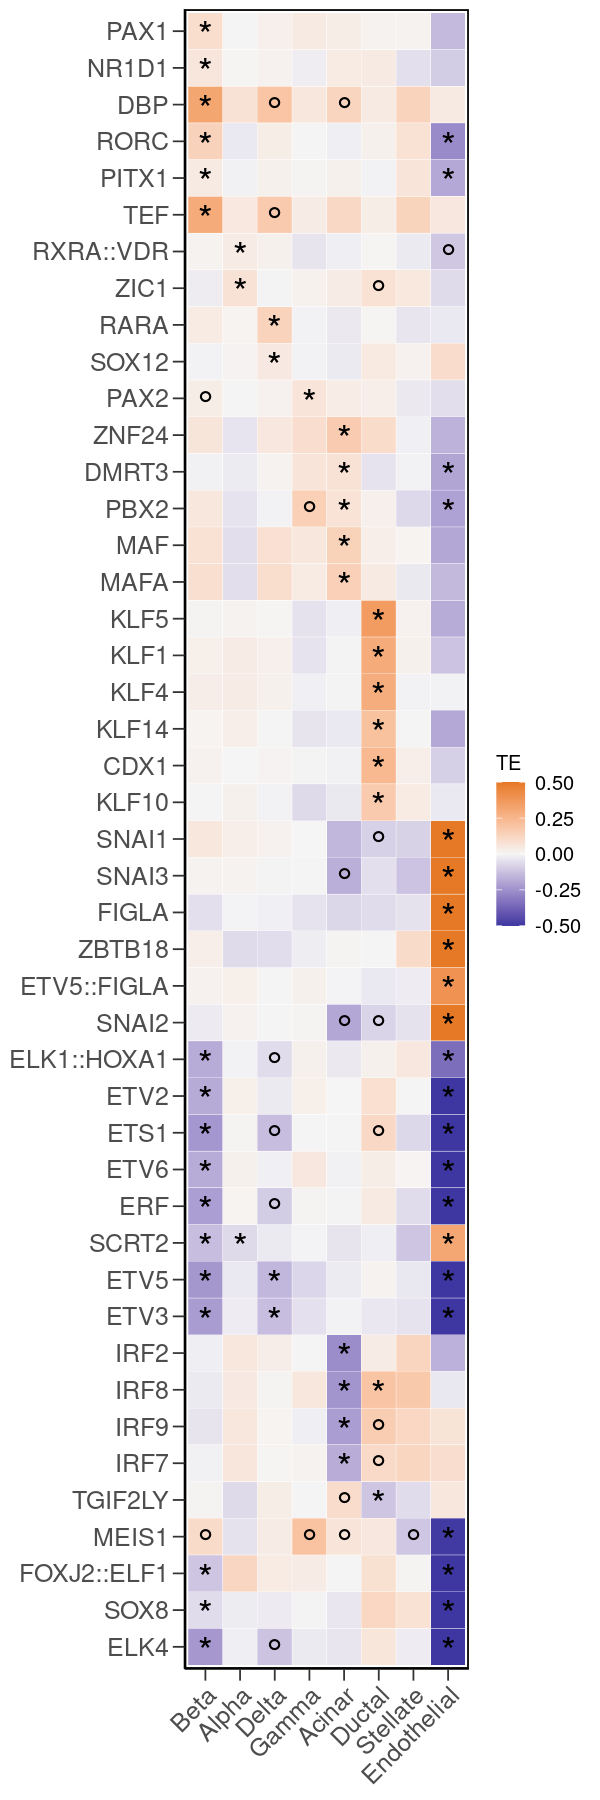

In [98]:
#get all the sig tf motifs by trait and make a heat map

spec_trait <- 'scaled_age'
sig_motifs1 <- c()
sig_motifs2 <- c()
for(ct in cell_types[-9]){
    ct_motifs1 <- subset(all_results, trait==spec_trait & qval < 0.1 & celltype==ct & TE>0) %>% 
                        arrange(qval) %>% pull(motif)
    sig_motifs1 <- c(sig_motifs1, head(ct_motifs1))
    ct_motifs2 <- subset(all_results, trait==spec_trait & qval < 0.1 & celltype==ct & TE<0) %>% 
                        arrange(qval) %>% pull(motif)
    sig_motifs2 <- c(sig_motifs2, head(ct_motifs2,5))
}

sig_motifs <- unique(c(sig_motifs1,sig_motifs2))
make_motif_pathway_plots(all_results, sig_motifs, spec_trait)

 [1] "SMAD3"       "SMAD5"       "FOXG1"       "SMAD2"       "NR6A1"      
 [6] "SCRT2"       "FOXO1::ELF1" "FOXO1::FLI1" "ESR2"        "TFAP2C"     
[11] "TFAP2B"      "ZKSCAN3"     "STAT1"       "TFAP2A"      "FOS"        
[16] "FOSL2"       "JDP2"        "NFE2"        "FOS::JUN"    "SREBF1"     
[21] "RORC"        "HOXA4"       "MEIS1"       "RXRA::VDR"   "MAF::NFE2"  
[26] "ELK1::HOXA1" "ZFP57"       "ETS1"        "HOXB2::ELK1" "ETV2"       
[31] "ZIC1"        "HOXC13"      "HES6"        "ZNF343"      "HEY1"       
[36] "E2F1"        "ZNF417"      "RORA"        "ZBTB7B"      "ZBTB7C"     
[41] "RARA"        "NR2C2"       "CTCF"        "CTCFL"       "FOXJ2::ELF1"
[46] "ZNF354A"    


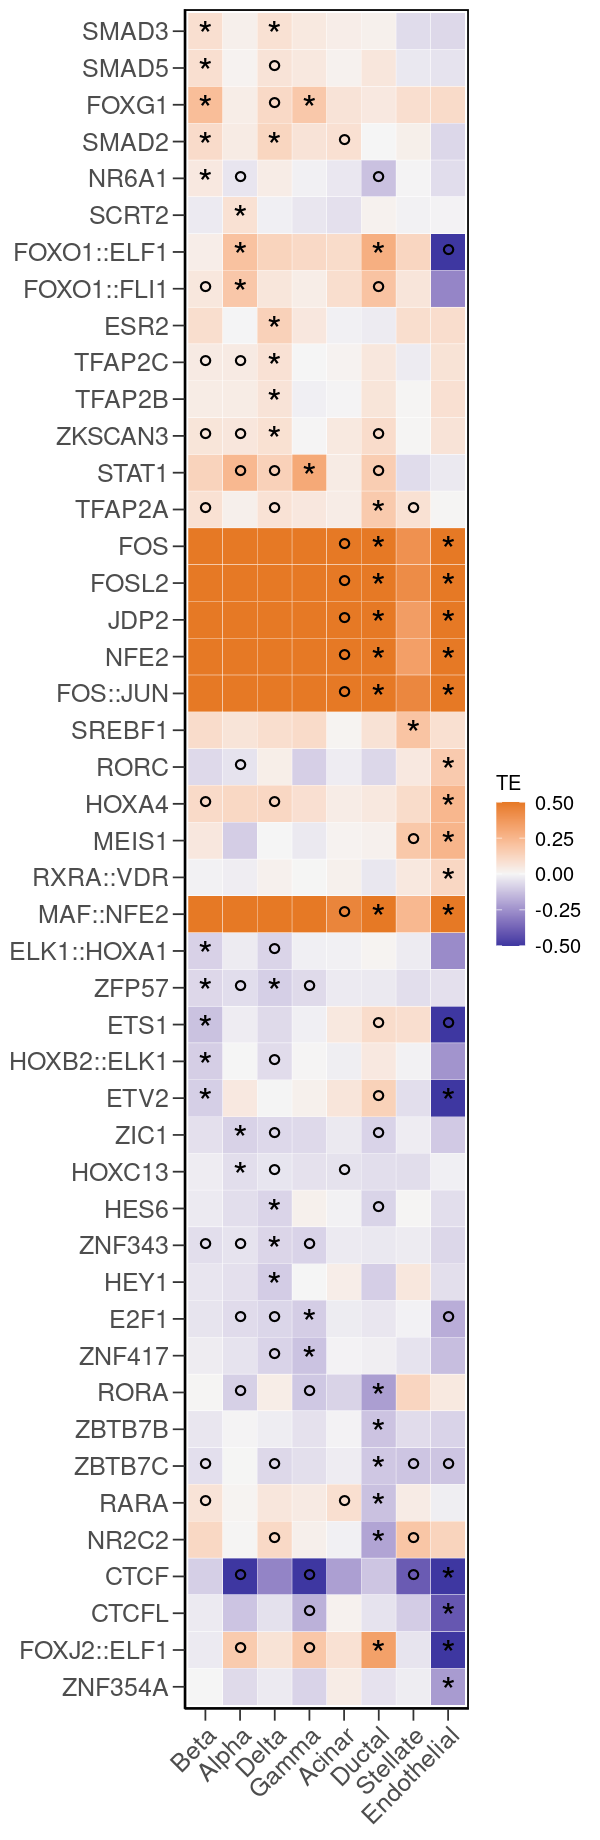

In [99]:
#get all the sig tf motifs by trait and make a heat map

spec_trait <- 'scaled_BMI'
sig_motifs1 <- c()
sig_motifs2 <- c()
for(ct in cell_types[-9]){
    ct_motifs1 <- subset(all_results, trait==spec_trait & qval < 0.1 & celltype==ct & TE>0) %>% 
                        arrange(qval) %>% pull(motif)
    sig_motifs1 <- c(sig_motifs1, head(ct_motifs1))
    ct_motifs2 <- subset(all_results, trait==spec_trait & qval < 0.1 & celltype==ct & TE<0) %>% 
                        arrange(qval) %>% pull(motif)
    sig_motifs2 <- c(sig_motifs2, head(ct_motifs2,5))
}

sig_motifs <- unique(c(sig_motifs1,sig_motifs2))
make_motif_pathway_plots(all_results, sig_motifs, spec_trait)

 [1] "ELK1::HOXA1" "KLF5"        "ZNF282"      "KLF15"       "KLF4"       
 [6] "KLF9"        "OTX2"        "RORC"        "RFX7"        "HOXA9"      
[11] "ZNF76"       "FOXD3"       "DBP"         "POU6F2"      "FOXG1"      
[16] "FOXP2"       "FOXI1"       "FOXL1"       "NKX2-8"      "FOXO4"      
[21] "PBX3"        "ZBTB6"       "PKNOX1"      "ZNF574"      "ZKSCAN3"    


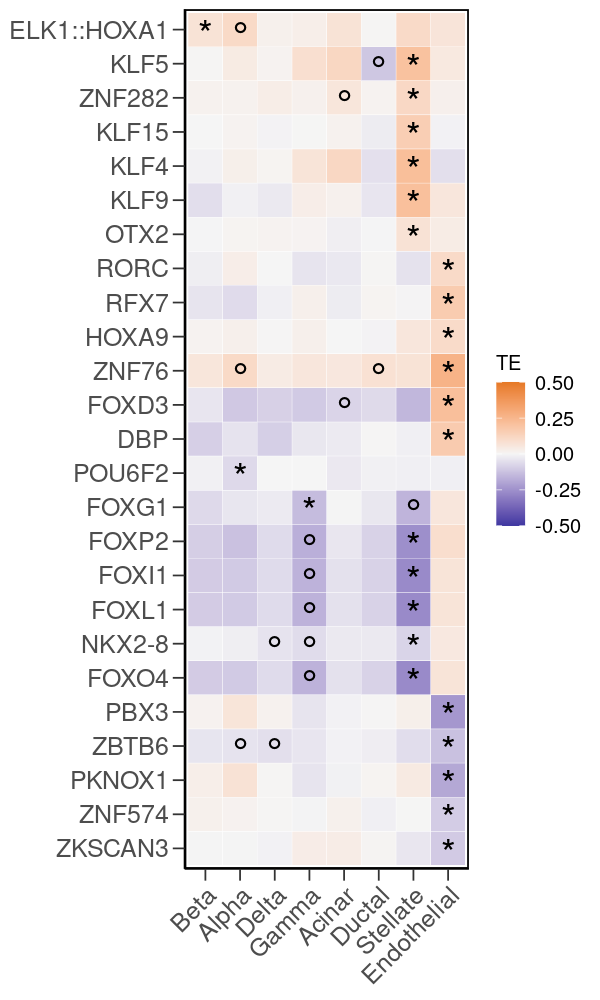

In [100]:
#get all the sig tf motifs by trait and make a heat map

spec_trait <- 'scaled_HbA1c'
sig_motifs1 <- c()
sig_motifs2 <- c()
for(ct in cell_types[-9]){
    ct_motifs1 <- subset(all_results, trait==spec_trait & qval < 0.1 & celltype==ct & TE>0) %>% 
                        arrange(qval) %>% pull(motif)
    sig_motifs1 <- c(sig_motifs1, head(ct_motifs1))
    ct_motifs2 <- subset(all_results, trait==spec_trait & qval < 0.1 & celltype==ct & TE<0) %>% 
                        arrange(qval) %>% pull(motif)
    sig_motifs2 <- c(sig_motifs2, head(ct_motifs2,5))
}

sig_motifs <- unique(c(sig_motifs1,sig_motifs2))
make_motif_pathway_plots(all_results, sig_motifs, spec_trait)

 [1] "TFAP2E"      "SCRT2"       "FOXO1::FLI1" "EBF1"        "FOXO1::ELF1"
 [6] "ARNT::HIF1A" "GLIS3"       "ZNF24"       "CTCF"        "BCL6"       
[11] "ZNF343"      "OVOL1"       "NFIC"        "ERF::NHLH1"  "GFI1"       
[16] "NFYC"        "NFYA"        "BARHL1"      "ZNF382"      "ZSCAN4"     
[21] "MEIS1"       "POU1F1"      "GBX2"        "HOXC4"      


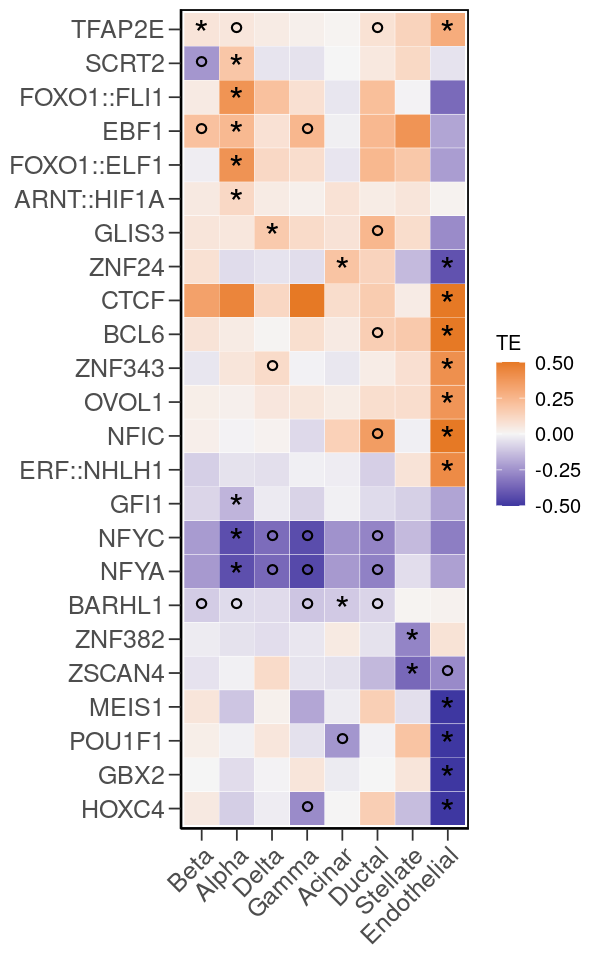

In [101]:
#get all the sig tf motifs by trait and make a heat map

spec_trait <- 'sex'
sig_motifs1 <- c()
sig_motifs2 <- c()
for(ct in cell_types[-9]){
    ct_motifs1 <- subset(all_results, trait==spec_trait & qval < 0.1 & celltype==ct & TE>0) %>% 
                        arrange(qval) %>% pull(motif)
    sig_motifs1 <- c(sig_motifs1, head(ct_motifs1))
    ct_motifs2 <- subset(all_results, trait==spec_trait & qval < 0.1 & celltype==ct & TE<0) %>% 
                        arrange(qval) %>% pull(motif)
    sig_motifs2 <- c(sig_motifs2, head(ct_motifs2,5))
}

sig_motifs <- unique(c(sig_motifs1,sig_motifs2))
make_motif_pathway_plots(all_results, sig_motifs[-c(18,25)], spec_trait)